In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the clean dataset
df = pd.read_csv(r'C:\Users\Pranjal Shah\ecommerce-analytics\data\superstore_clean.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth']  = df['Order Date'].dt.to_period('M')

# Chart styling — makes everything look professional
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']       = 130
plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print(f"Ready for EDA ✓  |  {df.shape[0]:,} rows × {df.shape[1]} columns")

Ready for EDA ✓  |  9,994 rows × 28 columns


In [2]:
print("=" * 45)
print("   BUSINESS PERFORMANCE SNAPSHOT")
print("=" * 45)

total_sales    = df['Sales'].sum()
total_profit   = df['Profit'].sum()
overall_margin = (total_profit / total_sales * 100)
total_orders   = df['Order ID'].nunique()
total_customers= df['Customer ID'].nunique()
avg_order_val  = total_sales / total_orders

print(f"  Total Revenue      : ${total_sales:>12,.0f}")
print(f"  Total Profit       : ${total_profit:>12,.0f}")
print(f"  Profit Margin      : {overall_margin:>11.1f}%")
print(f"  Unique Orders      : {total_orders:>12,}")
print(f"  Unique Customers   : {total_customers:>12,}")
print(f"  Avg Order Value    : ${avg_order_val:>12,.0f}")
print("=" * 45)

   BUSINESS PERFORMANCE SNAPSHOT
  Total Revenue      : $   2,297,201
  Total Profit       : $     286,397
  Profit Margin      :        12.5%
  Unique Orders      :        5,009
  Unique Customers   :          793
  Avg Order Value    : $         459


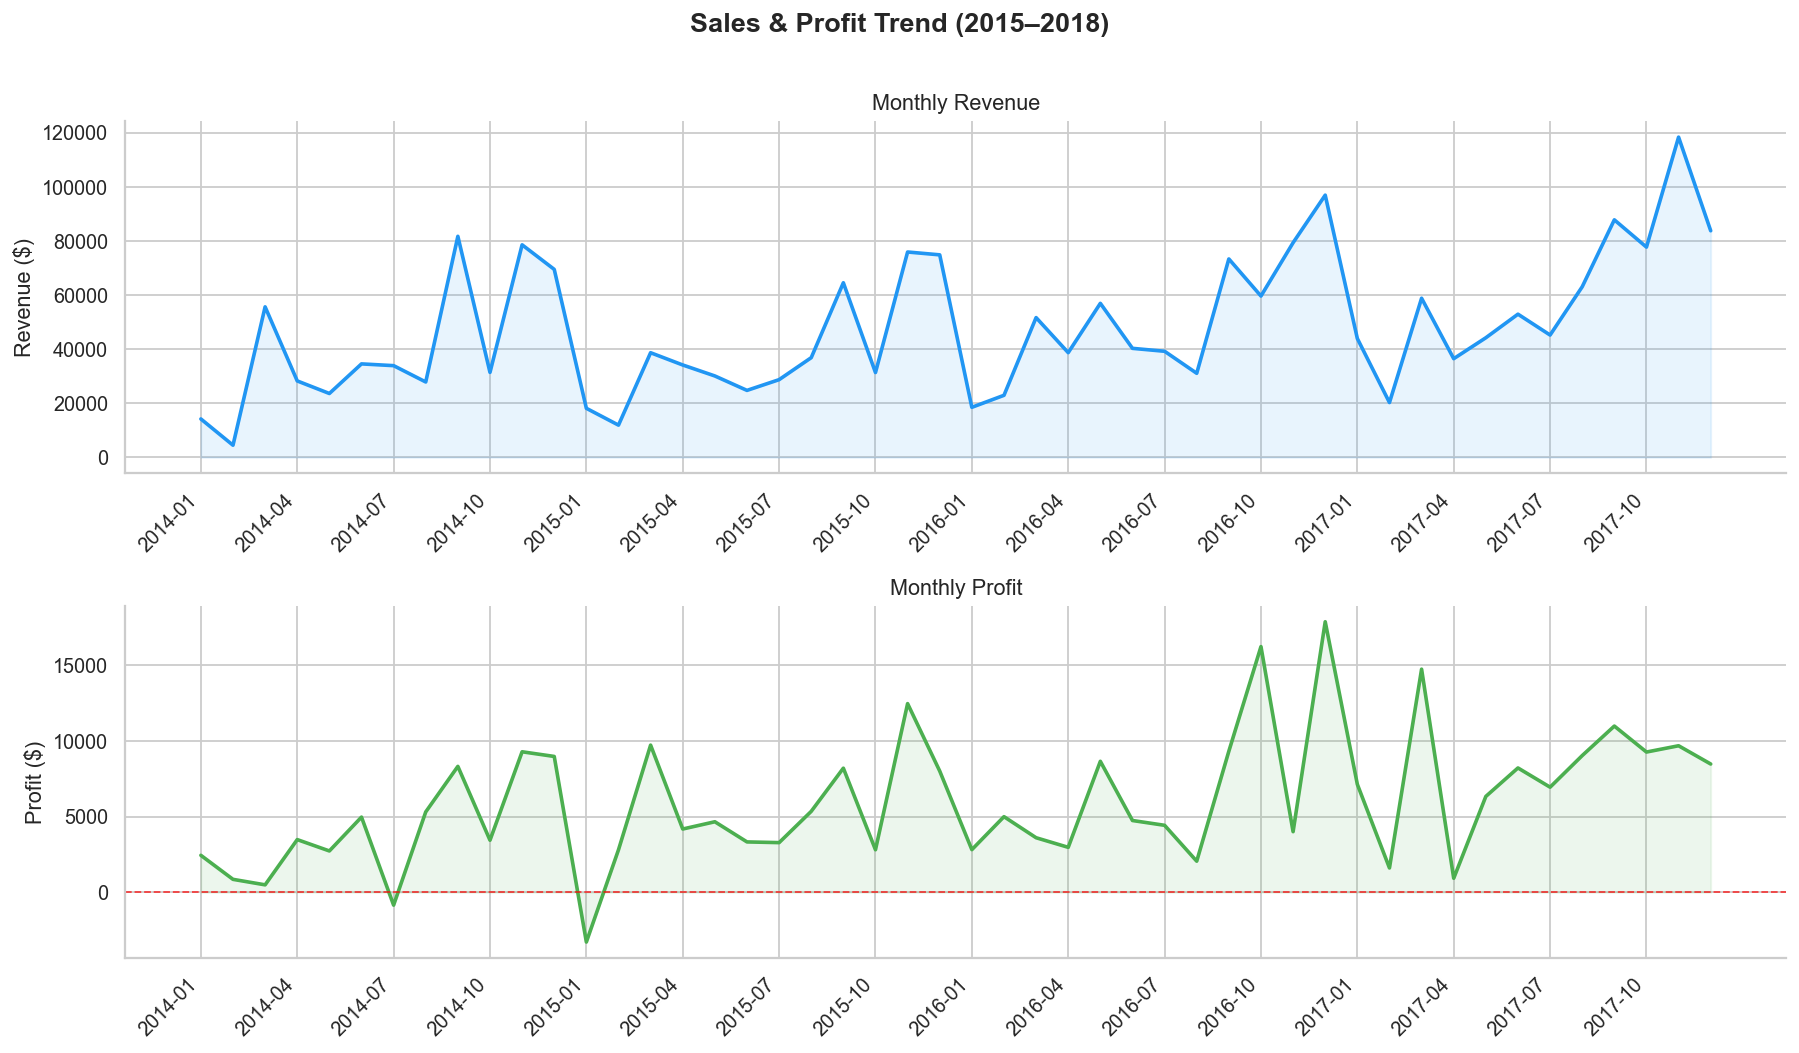

Chart saved ✓


In [3]:
# Monthly aggregation
monthly = df.groupby('YearMonth').agg(
    Sales  = ('Sales','sum'),
    Profit = ('Profit','sum')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Sales & Profit Trend (2015–2018)', fontsize=15, fontweight='bold', y=1.01)

# Sales trend
axes[0].plot(monthly['YearMonth'], monthly['Sales'], color='#2196F3', linewidth=2)
axes[0].fill_between(range(len(monthly)), monthly['Sales'], alpha=0.1, color='#2196F3')
axes[0].set_title('Monthly Revenue', fontsize=12)
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xticks(range(0, len(monthly), 3))
axes[0].set_xticklabels(monthly['YearMonth'][::3], rotation=45, ha='right')

# Profit trend
axes[1].plot(monthly['YearMonth'], monthly['Profit'], color='#4CAF50', linewidth=2)
axes[1].fill_between(range(len(monthly)), monthly['Profit'], alpha=0.1, color='#4CAF50')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_title('Monthly Profit', fontsize=12)
axes[1].set_ylabel('Profit ($)')
axes[1].set_xticks(range(0, len(monthly), 3))
axes[1].set_xticklabels(monthly['YearMonth'][::3], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(r'C:\Users\Pranjal Shah\ecommerce-analytics\visuals\01_sales_profit_trend.png',
            bbox_inches='tight')
plt.show()
print("Chart saved ✓")

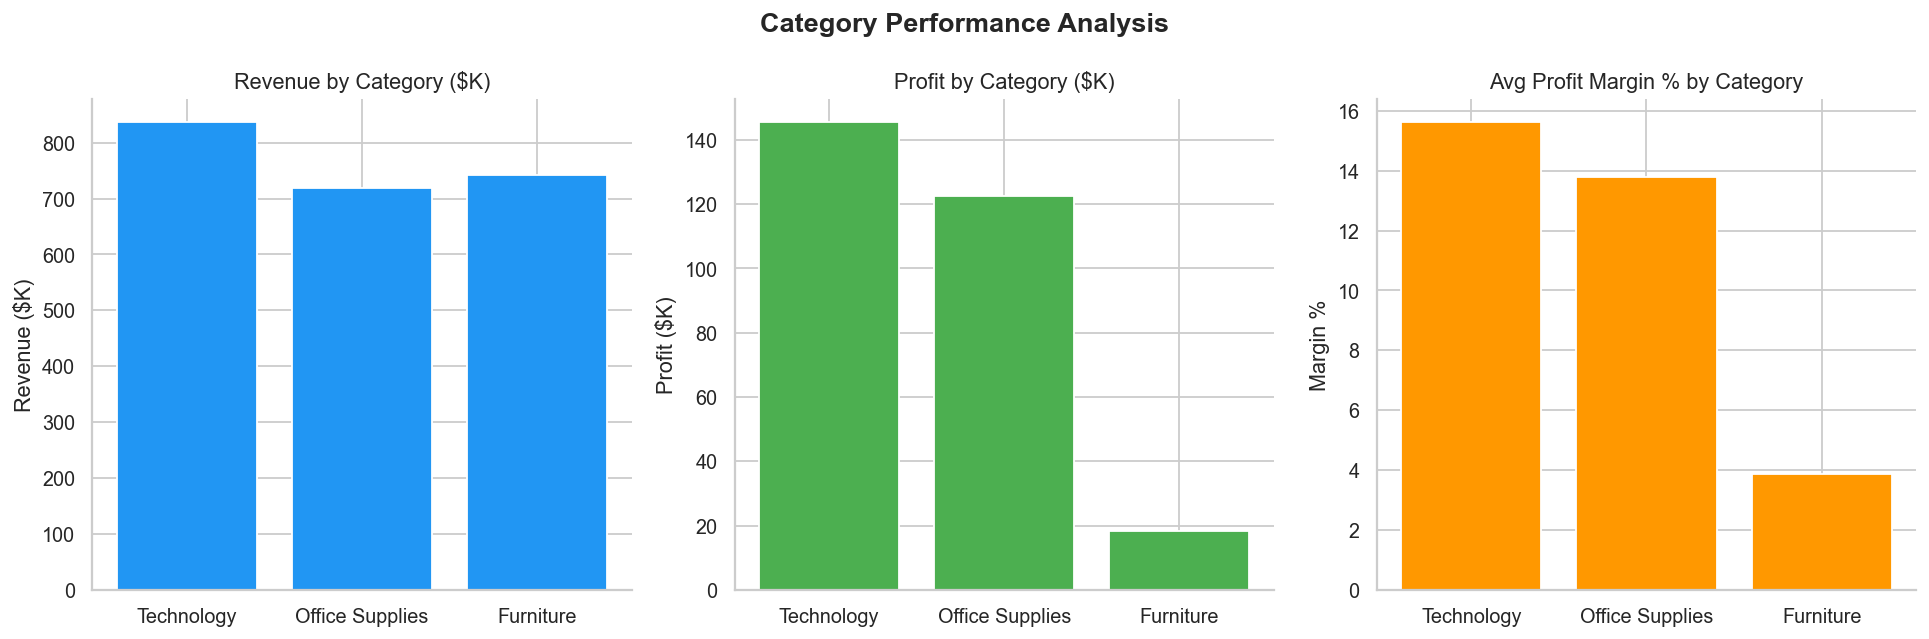


Category Summary:
       Category       Sales      Profit  Profit_Margin
     Technology 836154.0330 145454.9481      15.613812
Office Supplies 719047.0320 122490.8008      13.803032
      Furniture 741999.7953  18451.2728       3.878326


In [4]:
category = df.groupby('Category').agg(
    Sales         = ('Sales','sum'),
    Profit        = ('Profit','sum'),
    Profit_Margin = ('Profit Margin %','mean')
).reset_index().sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Category Performance Analysis', fontsize=15, fontweight='bold')

colors = ['#4CAF50' if x > 0 else '#F44336' for x in category['Profit']]

# Sales by category
axes[0].bar(category['Category'], category['Sales']/1000, color='#2196F3', edgecolor='white')
axes[0].set_title('Revenue by Category ($K)')
axes[0].set_ylabel('Revenue ($K)')

# Profit by category
axes[1].bar(category['Category'], category['Profit']/1000, color=colors, edgecolor='white')
axes[1].set_title('Profit by Category ($K)')
axes[1].set_ylabel('Profit ($K)')
axes[1].axhline(0, color='black', linewidth=0.8)

# Margin by category
axes[2].bar(category['Category'], category['Profit_Margin'], color='#FF9800', edgecolor='white')
axes[2].set_title('Avg Profit Margin % by Category')
axes[2].set_ylabel('Margin %')

plt.tight_layout()
plt.savefig(r'C:\Users\Pranjal Shah\ecommerce-analytics\visuals\02_category_performance.png',
            bbox_inches='tight')
plt.show()

print("\nCategory Summary:")
print(category[['Category','Sales','Profit','Profit_Margin']].to_string(index=False))

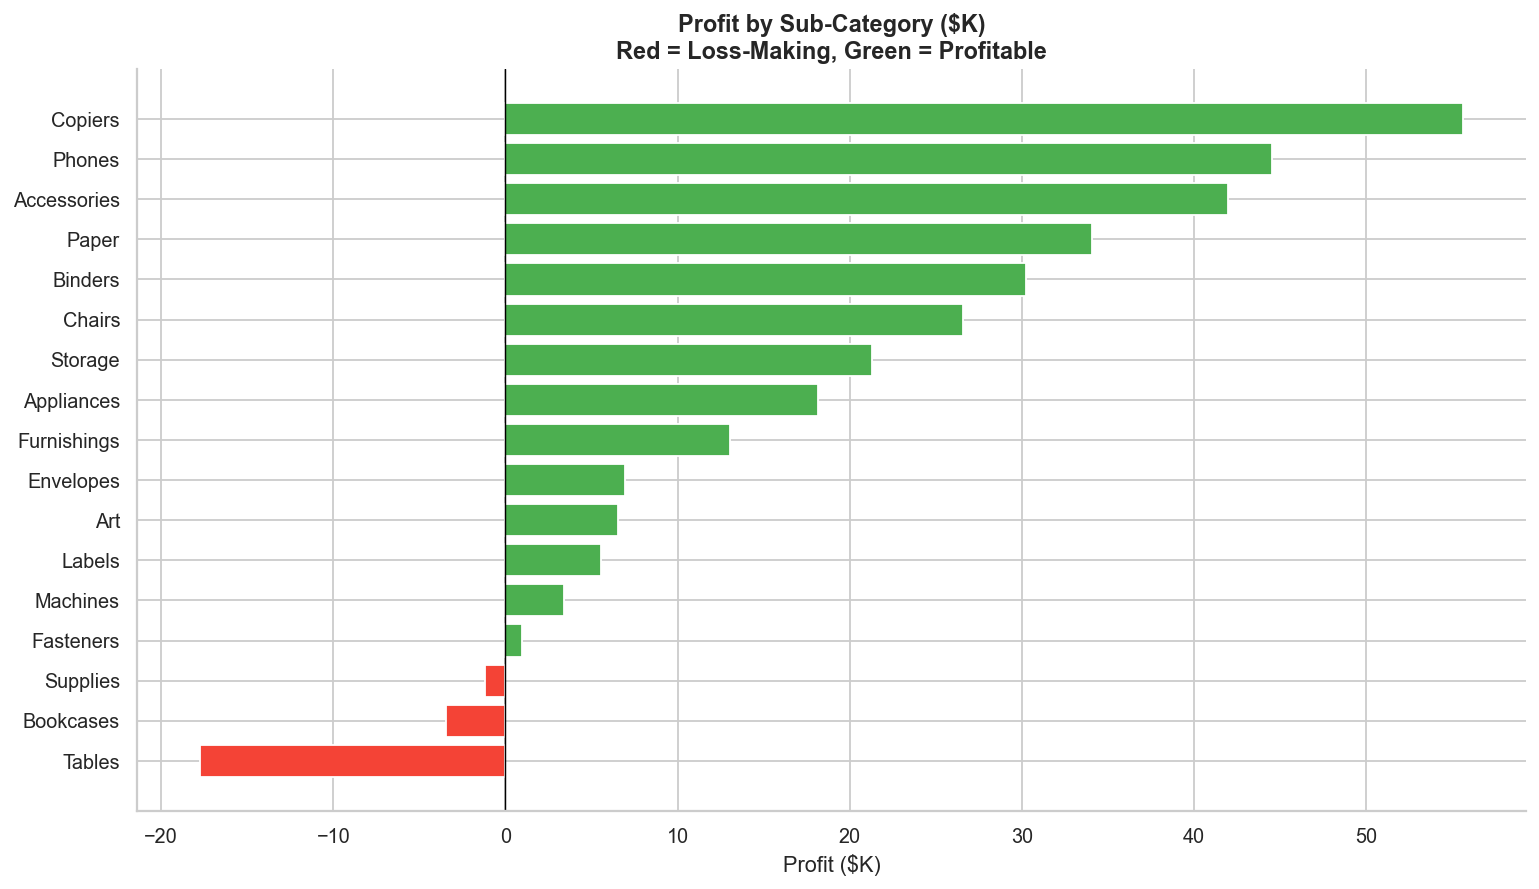

Chart saved ✓


In [5]:
subcat = df.groupby('Sub-Category').agg(
    Sales  = ('Sales','sum'),
    Profit = ('Profit','sum')
).reset_index().sort_values('Profit')

colors = ['#F44336' if x < 0 else '#4CAF50' for x in subcat['Profit']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(subcat['Sub-Category'], subcat['Profit']/1000, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Profit by Sub-Category ($K)\nRed = Loss-Making, Green = Profitable',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Profit ($K)')

plt.tight_layout()
plt.savefig(r'C:\Users\Pranjal Shah\ecommerce-analytics\visuals\03_subcategory_profit.png',
            bbox_inches='tight')
plt.show()
print("Chart saved ✓")


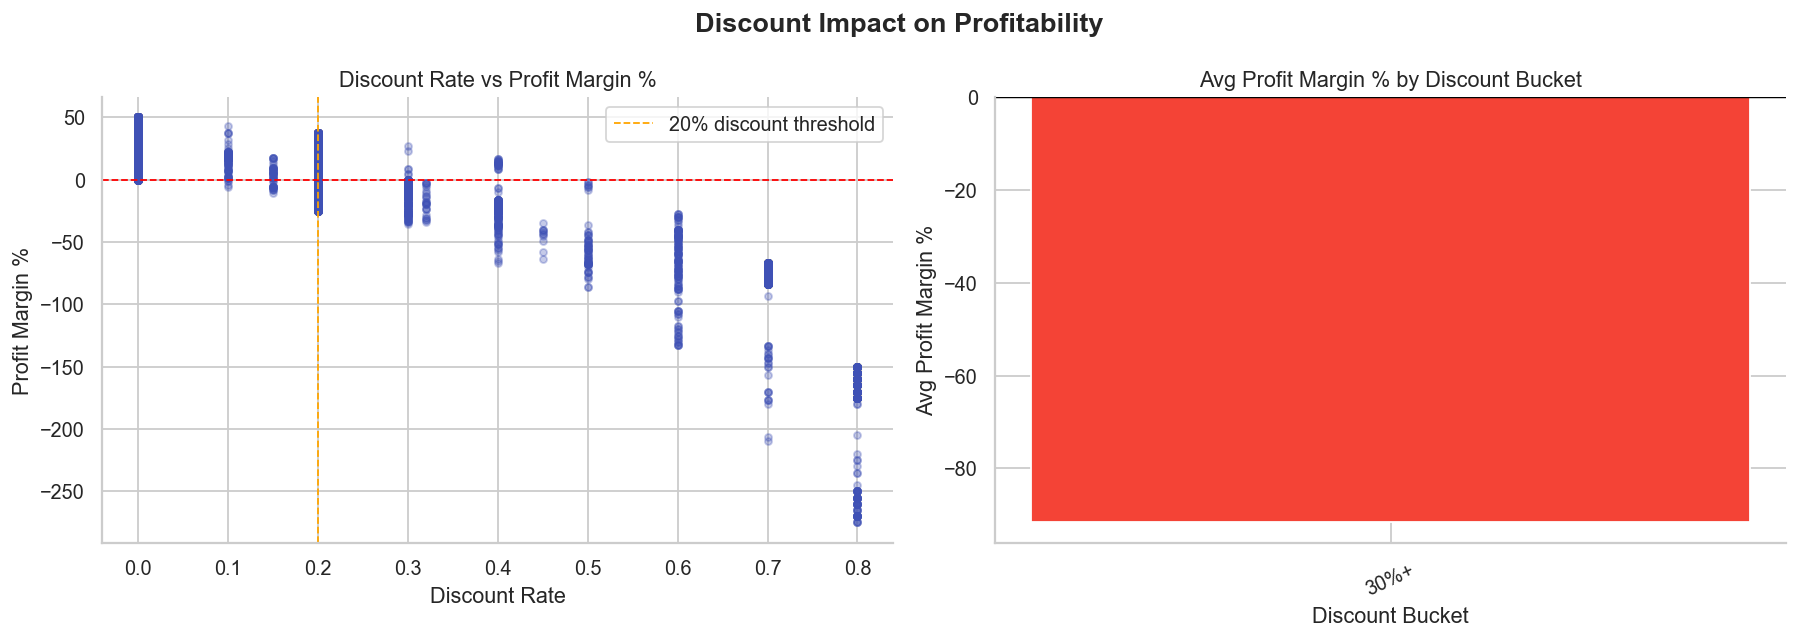

Chart saved ✓


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Discount Impact on Profitability', fontsize=15, fontweight='bold')

# Scatter plot
axes[0].scatter(df['Discount'], df['Profit Margin %'],
                alpha=0.3, color='#3F51B5', s=15)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].axvline(0.2, color='orange', linestyle='--', linewidth=1, label='20% discount threshold')
axes[0].set_title('Discount Rate vs Profit Margin %')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit Margin %')
axes[0].legend()

# Average profit margin by discount bucket
bucket_order  = ['0% — No Discount','1–10%','11–20%','21–30%','30%+']
bucket_margin = df.groupby('Discount Bucket')['Profit Margin %'].mean().reindex(bucket_order)
bar_colors    = ['#4CAF50' if x > 0 else '#F44336' for x in bucket_margin.values]

axes[1].bar(bucket_margin.index, bucket_margin.values, color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Profit Margin % by Discount Bucket')
axes[1].set_xlabel('Discount Bucket')
axes[1].set_ylabel('Avg Profit Margin %')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(r'C:\Users\Pranjal Shah\ecommerce-analytics\visuals\04_discount_profit.png',
            bbox_inches='tight')
plt.show()
print("Chart saved ✓")

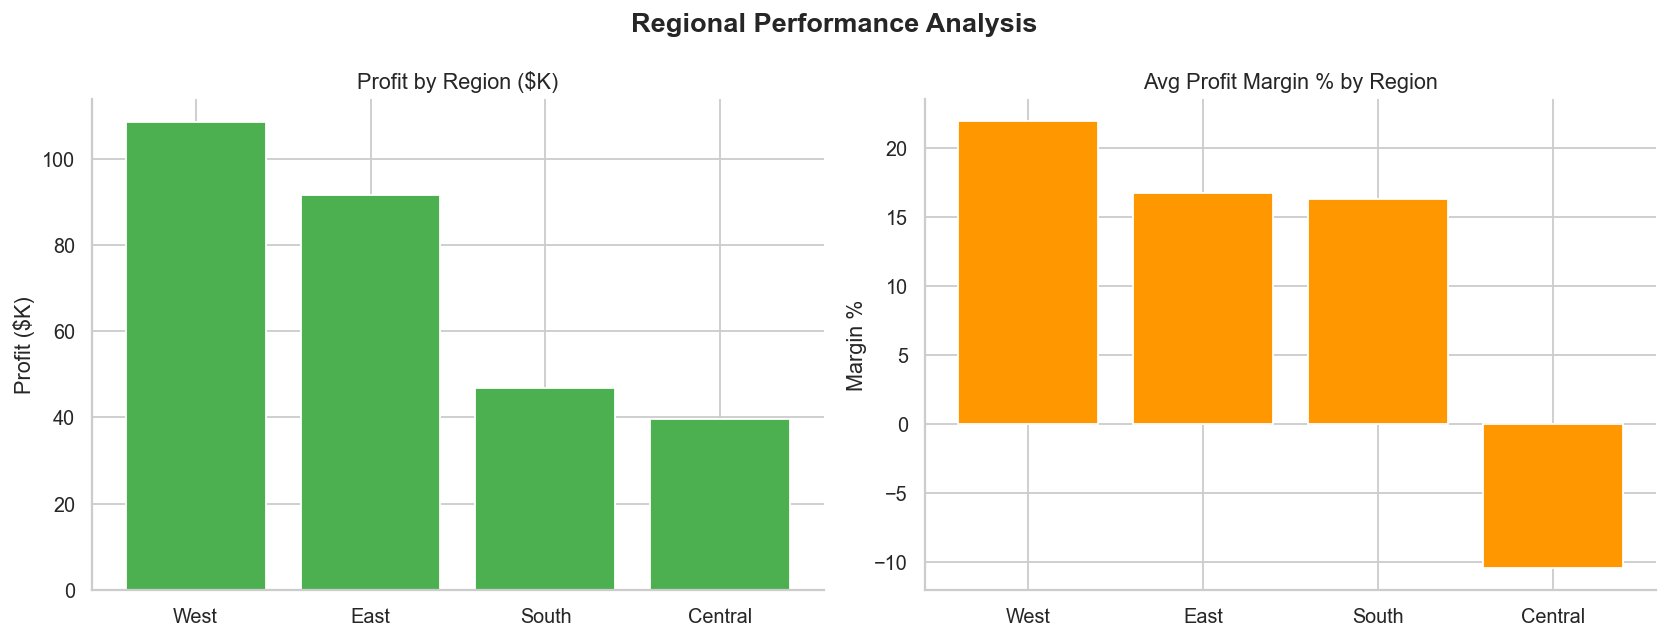


Regional Summary:
 Region       Sales      Profit  Profit_Margin  Orders
   West 725457.8245 108418.4489      21.948667    1611
   East 678781.2400  91522.7800      16.722711    1401
  South 391721.9050  46749.4303      16.351877     822
Central 501239.8908  39706.3625     -10.407314    1175


In [7]:
region = df.groupby('Region').agg(
    Sales         = ('Sales','sum'),
    Profit        = ('Profit','sum'),
    Profit_Margin = ('Profit Margin %','mean'),
    Orders        = ('Order ID','nunique')
).reset_index().sort_values('Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Regional Performance Analysis', fontsize=15, fontweight='bold')

colors = ['#4CAF50' if x > 0 else '#F44336' for x in region['Profit']]

axes[0].bar(region['Region'], region['Profit']/1000, color=colors, edgecolor='white')
axes[0].set_title('Profit by Region ($K)')
axes[0].set_ylabel('Profit ($K)')
axes[0].axhline(0, color='black', linewidth=0.8)

axes[1].bar(region['Region'], region['Profit_Margin'], color='#FF9800', edgecolor='white')
axes[1].set_title('Avg Profit Margin % by Region')
axes[1].set_ylabel('Margin %')

plt.tight_layout()
plt.savefig(r'C:\Users\Pranjal Shah\ecommerce-analytics\visuals\05_regional_performance.png',
            bbox_inches='tight')
plt.show()

print("\nRegional Summary:")
print(region[['Region','Sales','Profit','Profit_Margin','Orders']].to_string(index=False))

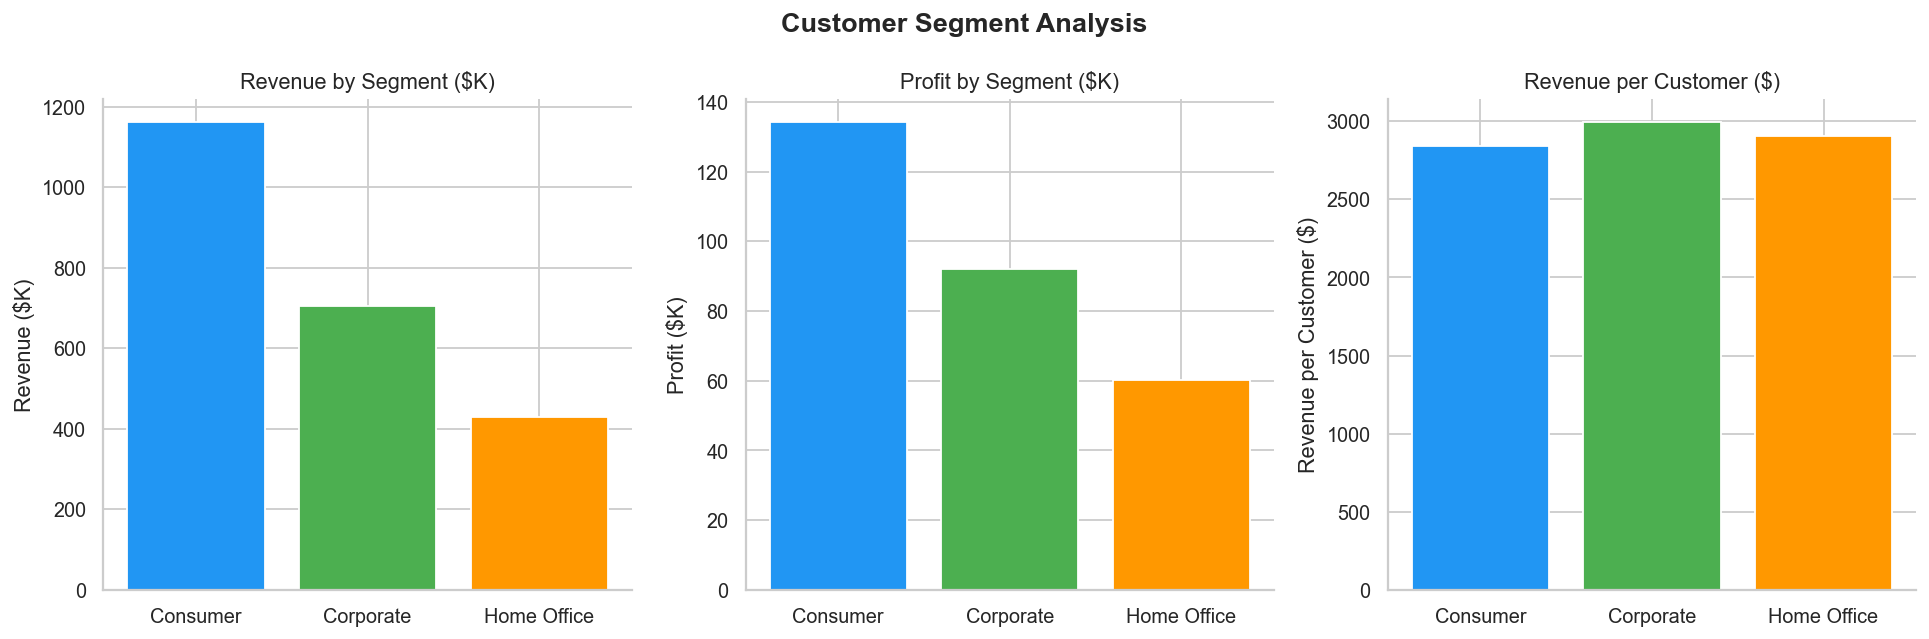


Segment Summary:
    Segment        Sales      Profit  Profit_Margin  Revenue per Customer
   Consumer 1161401.3450 134119.2092      11.204955           2839.612090
  Corporate  706146.3668  91979.1340      12.120238           2992.145622
Home Office  429653.1485  60298.6785      14.286971           2903.061814


In [8]:
segment = df.groupby('Segment').agg(
    Sales         = ('Sales','sum'),
    Profit        = ('Profit','sum'),
    Profit_Margin = ('Profit Margin %','mean'),
    Customers     = ('Customer ID','nunique'),
    Orders        = ('Order ID','nunique')
).reset_index()
segment['Revenue per Customer'] = segment['Sales'] / segment['Customers']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Segment Analysis', fontsize=15, fontweight='bold')

axes[0].bar(segment['Segment'], segment['Sales']/1000,
            color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
axes[0].set_title('Revenue by Segment ($K)')
axes[0].set_ylabel('Revenue ($K)')

axes[1].bar(segment['Segment'], segment['Profit']/1000,
            color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
axes[1].set_title('Profit by Segment ($K)')
axes[1].set_ylabel('Profit ($K)')

axes[2].bar(segment['Segment'], segment['Revenue per Customer'],
            color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
axes[2].set_title('Revenue per Customer ($)')
axes[2].set_ylabel('Revenue per Customer ($)')

plt.tight_layout()
plt.savefig(r'C:\Users\Pranjal Shah\ecommerce-analytics\visuals\06_segment_analysis.png',
            bbox_inches='tight')
plt.show()

print("\nSegment Summary:")
print(segment[['Segment','Sales','Profit','Profit_Margin','Revenue per Customer']].to_string(index=False))

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the clean dataset
df = pd.read_csv(r'C:\Users\Pranjal Shah\ecommerce-analytics\data\superstore_clean.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth']  = df['Order Date'].dt.to_period('M')

# Chart styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f"Ready for EDA ✓  |  {df.shape[0]:,} rows × {df.shape[1]} columns")

Ready for EDA ✓  |  9,994 rows × 28 columns


In [10]:
print("=" * 50)
print("   COMPLETE EDA SUMMARY")
print("=" * 50)

# Overall
print("\n--- OVERALL BUSINESS ---")
print(f"Total Revenue    : ${df['Sales'].sum():,.0f}")
print(f"Total Profit     : ${df['Profit'].sum():,.0f}")
print(f"Overall Margin   : {(df['Profit'].sum()/df['Sales'].sum()*100):.1f}%")

# By Category
print("\n--- BY CATEGORY ---")
cat = df.groupby('Category')[['Sales','Profit']].sum()
cat['Margin %'] = (cat['Profit']/cat['Sales']*100).round(1)
print(cat.to_string())

# By Region
print("\n--- BY REGION ---")
reg = df.groupby('Region')[['Sales','Profit']].sum()
reg['Margin %'] = (reg['Profit']/reg['Sales']*100).round(1)
print(reg.to_string())

# By Segment
print("\n--- BY SEGMENT ---")
seg = df.groupby('Segment')[['Sales','Profit']].sum()
seg['Margin %'] = (seg['Profit']/seg['Sales']*100).round(1)
print(seg.to_string())

# Discount impact
print("\n--- DISCOUNT IMPACT ---")
bucket_order = ['0% — No Discount','1–10%','11–20%','21–30%','30%+']
disc = df.groupby('Discount Bucket')['Profit Margin %'].mean().reindex(bucket_order).round(1)
print(disc.to_string())

# Worst sub-categories
print("\n--- BOTTOM 5 SUB-CATEGORIES BY PROFIT ---")
worst = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(5)
print(worst.to_string())

   COMPLETE EDA SUMMARY

--- OVERALL BUSINESS ---
Total Revenue    : $2,297,201
Total Profit     : $286,397
Overall Margin   : 12.5%

--- BY CATEGORY ---
                       Sales       Profit  Margin %
Category                                           
Furniture        741999.7953   18451.2728       2.5
Office Supplies  719047.0320  122490.8008      17.0
Technology       836154.0330  145454.9481      17.4

--- BY REGION ---
               Sales       Profit  Margin %
Region                                     
Central  501239.8908   39706.3625       7.9
East     678781.2400   91522.7800      13.5
South    391721.9050   46749.4303      11.9
West     725457.8245  108418.4489      14.9

--- BY SEGMENT ---
                    Sales       Profit  Margin %
Segment                                         
Consumer     1.161401e+06  134119.2092      11.5
Corporate    7.061464e+05   91979.1340      13.0
Home Office  4.296531e+05   60298.6785      14.0

--- DISCOUNT IMPACT ---
Discount Buck

In [11]:
# Fix discount bucket summary
bucket_order = ['0% — No Discount','1–10%','11–20%','21–30%','30%+']
disc = df.groupby('Discount Bucket')['Profit Margin %'].mean().reindex(bucket_order).round(1)
print("--- DISCOUNT IMPACT (FIXED) ---")
print(disc.to_string())

# Also show count of orders in each bucket
disc_count = df.groupby('Discount Bucket')['Order ID'].count().reindex(bucket_order)
print("\n--- ORDER COUNT PER DISCOUNT BUCKET ---")
print(disc_count.to_string())

--- DISCOUNT IMPACT (FIXED) ---
Discount Bucket
0% — No Discount     NaN
1–10%                NaN
11–20%               NaN
21–30%               NaN
30%+               -91.5

--- ORDER COUNT PER DISCOUNT BUCKET ---
Discount Bucket
0% — No Discount       NaN
1–10%                  NaN
11–20%                 NaN
21–30%                 NaN
30%+                1166.0


In [12]:
# Rebuild Discount Bucket column from scratch
def discount_bucket(d):
    if d == 0:       return '0% — No Discount'
    elif d <= 0.10:  return '1-10%'
    elif d <= 0.20:  return '11-20%'
    elif d <= 0.30:  return '21-30%'
    else:            return '30%+'

df['Discount Bucket'] = df['Discount'].apply(discount_bucket)

# Now run the summary again
bucket_order = ['0% — No Discount','1-10%','11-20%','21-30%','30%+']

print("--- DISCOUNT IMPACT ---")
disc_margin = df.groupby('Discount Bucket')['Profit Margin %'].mean().reindex(bucket_order).round(1)
print(disc_margin.to_string())

print("\n--- ORDER COUNT PER BUCKET ---")
disc_count = df.groupby('Discount Bucket')['Order ID'].count().reindex(bucket_order)
print(disc_count.to_string())

--- DISCOUNT IMPACT ---
Discount Bucket
0% — No Discount    34.0
1-10%               15.6
11-20%              17.5
21-30%             -11.5
30%+               -91.5

--- ORDER COUNT PER BUCKET ---
Discount Bucket
0% — No Discount    4798
1-10%                 94
11-20%              3709
21-30%               227
30%+                1166
